# Samples from models on 60km -> 2.2km-4x over Birmingham

In [ ]:
%reload_ext autoreload

%autoreload 2

%reload_ext dotenv
%dotenv

In [ ]:
from mlde_analysis.default_params import *

In [ ]:
# Parameters
desc = "Comparison of diffusion model for CPMGEM-pr paper\nTest split\n12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set\nCompare techniques: diffusion, u-net, bilinear\n"
eval_vars = ["pr"]
derived_variables_config = {}
dataset_configs = {
    "CPM": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
    "GCM": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
}
split = "test"
ensemble_members = [
    "01",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "15",
]
samples_per_run = 6
sample_configs = {
    "CPM": [
        {
            "label": "CPMGEM_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:blue",
            "order": 11,
        },
        {
            "label": "U-Net_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/deterministic/ukcp_local_pr_12em_plain_unet/bham_pSTV-ema-gradcl-256-batch",
                    "checkpoint": "epoch_100",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": True,
            "color": "tab:orange",
            "order": 2,
        },
        {
            "label": "BCSD_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "bcsd-v1/ukcp_local_pr_12em-ws3",
                    "checkpoint": "epoch-0",
                    "input_xfm": "bham64_ccpm-4x_12em_linpr_pr-bcsd",
                    "dataset": "bham64_ccpm-4x_12em_linpr_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": True,
            "color": "tab:red",
            "order": 1,
            "UQ": True,
            "CCS": True,
        },
    ],
    "GCM": [
        {
            "label": "CPMGEM_GCM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-pixelmmsstan",
                    "dataset": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "UQ": False,
            "color": "tab:green",
            "order": 20,
        }
    ],
}
sample_configs_at_60km = [
    {
        "label": "CPMGEM_GCM@60km",
        "sample_specs": [
            {
                "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV/postprocess/gcm-grid",
                "checkpoint": "epoch_20",
                "input_xfm": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-pixelmmsstan",
                "dataset": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                "variables": ["pr"],
            }
        ],
        "deterministic": False,
    }
]
dataset_configs_at_60km = {
    "CPM": "bham64_ccpm-60km_12em_pr_pr",
    "GCM": "bham64_gcm-60km_12em_rawpr_pr",
}
example_percentiles = {
    "CPM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    },
    "GCM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    },
}
example_overrides = {"CPM": {"JJA Wet": ["01", "1993-08-01 12:00:00"]}, "GCM": {}}
examples_sample_idxs = [2, 5]
niterations = 30
bootstrap_configs = {"niterations": {"spread-error": 50}}


In [ ]:
import IPython
import matplotlib
import matplotlib.pyplot as plt

from mlde_analysis.data import prep_eval_data
from mlde_analysis.examples import plot_examples, em_timestamps

In [ ]:
matplotlib.rcParams['figure.dpi'] = 300

In [ ]:
IPython.display.Markdown(desc)

Comparison of diffusion model for CPMGEM-pr paper
Test split
12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set
Compare techniques: diffusion, u-net, bilinear


In [ ]:
%reload_ext mlde_analysis.magics 
EVAL_DS, MODELS, CPM_DAS, PRED_DAS, VAR_DAS, MODELLABEL2SPEC = %load_eval_data
EVAL_DS

{'CPM': <xarray.Dataset> Size: 34GB
 Dimensions:                     (model: 3, sample_id: 6, ensemble_member: 12,
                                  time: 3240, grid_latitude: 64,
                                  grid_longitude: 64, bnds: 2)
 Coordinates:
   * ensemble_member             (ensemble_member) <U2 96B '01' '04' ... '15'
   * time                        (time) object 26kB 1981-03-01 12:00:00 ... 20...
     season                      (time) int64 26kB 1 1 1 1 1 1 1 ... 2 2 2 2 2 2
   * grid_latitude               (grid_latitude) float32 256B -2.49 ... 2.55
   * grid_longitude              (grid_longitude) float32 256B 357.9 ... 363.0
     time_period                 (time) <U8 104kB 'historic' ... 'future'
   * model                       (model) object 24B 'CPMGEM_cCPM' ... 'BCSD_cCPM'
     dec_adjusted_year           (time) int64 26kB 1981 1981 1981 ... 2076 2076
     stratum                     (time) <U12 156kB 'historic MAM' ... 'future ...
     tp_season_year         

In [ ]:
examples_to_plot = {}

for source, percentiles in example_percentiles.items():
    em_ts = em_timestamps(EVAL_DS[source], percentiles=percentiles, overrides=example_overrides[source])

    examples_to_plot[source] = em_ts

CPM Samples

DJF Wet sample requested for EM06 on 2035-02-07 12:00:00


DJF Wettest sample requested for EM01 on 2029-12-04 12:00:00
JJA Wet sample requested for EM01 on 1993-08-01 12:00:00


JJA Wettest sample requested for EM01 on 2073-07-30 12:00:00


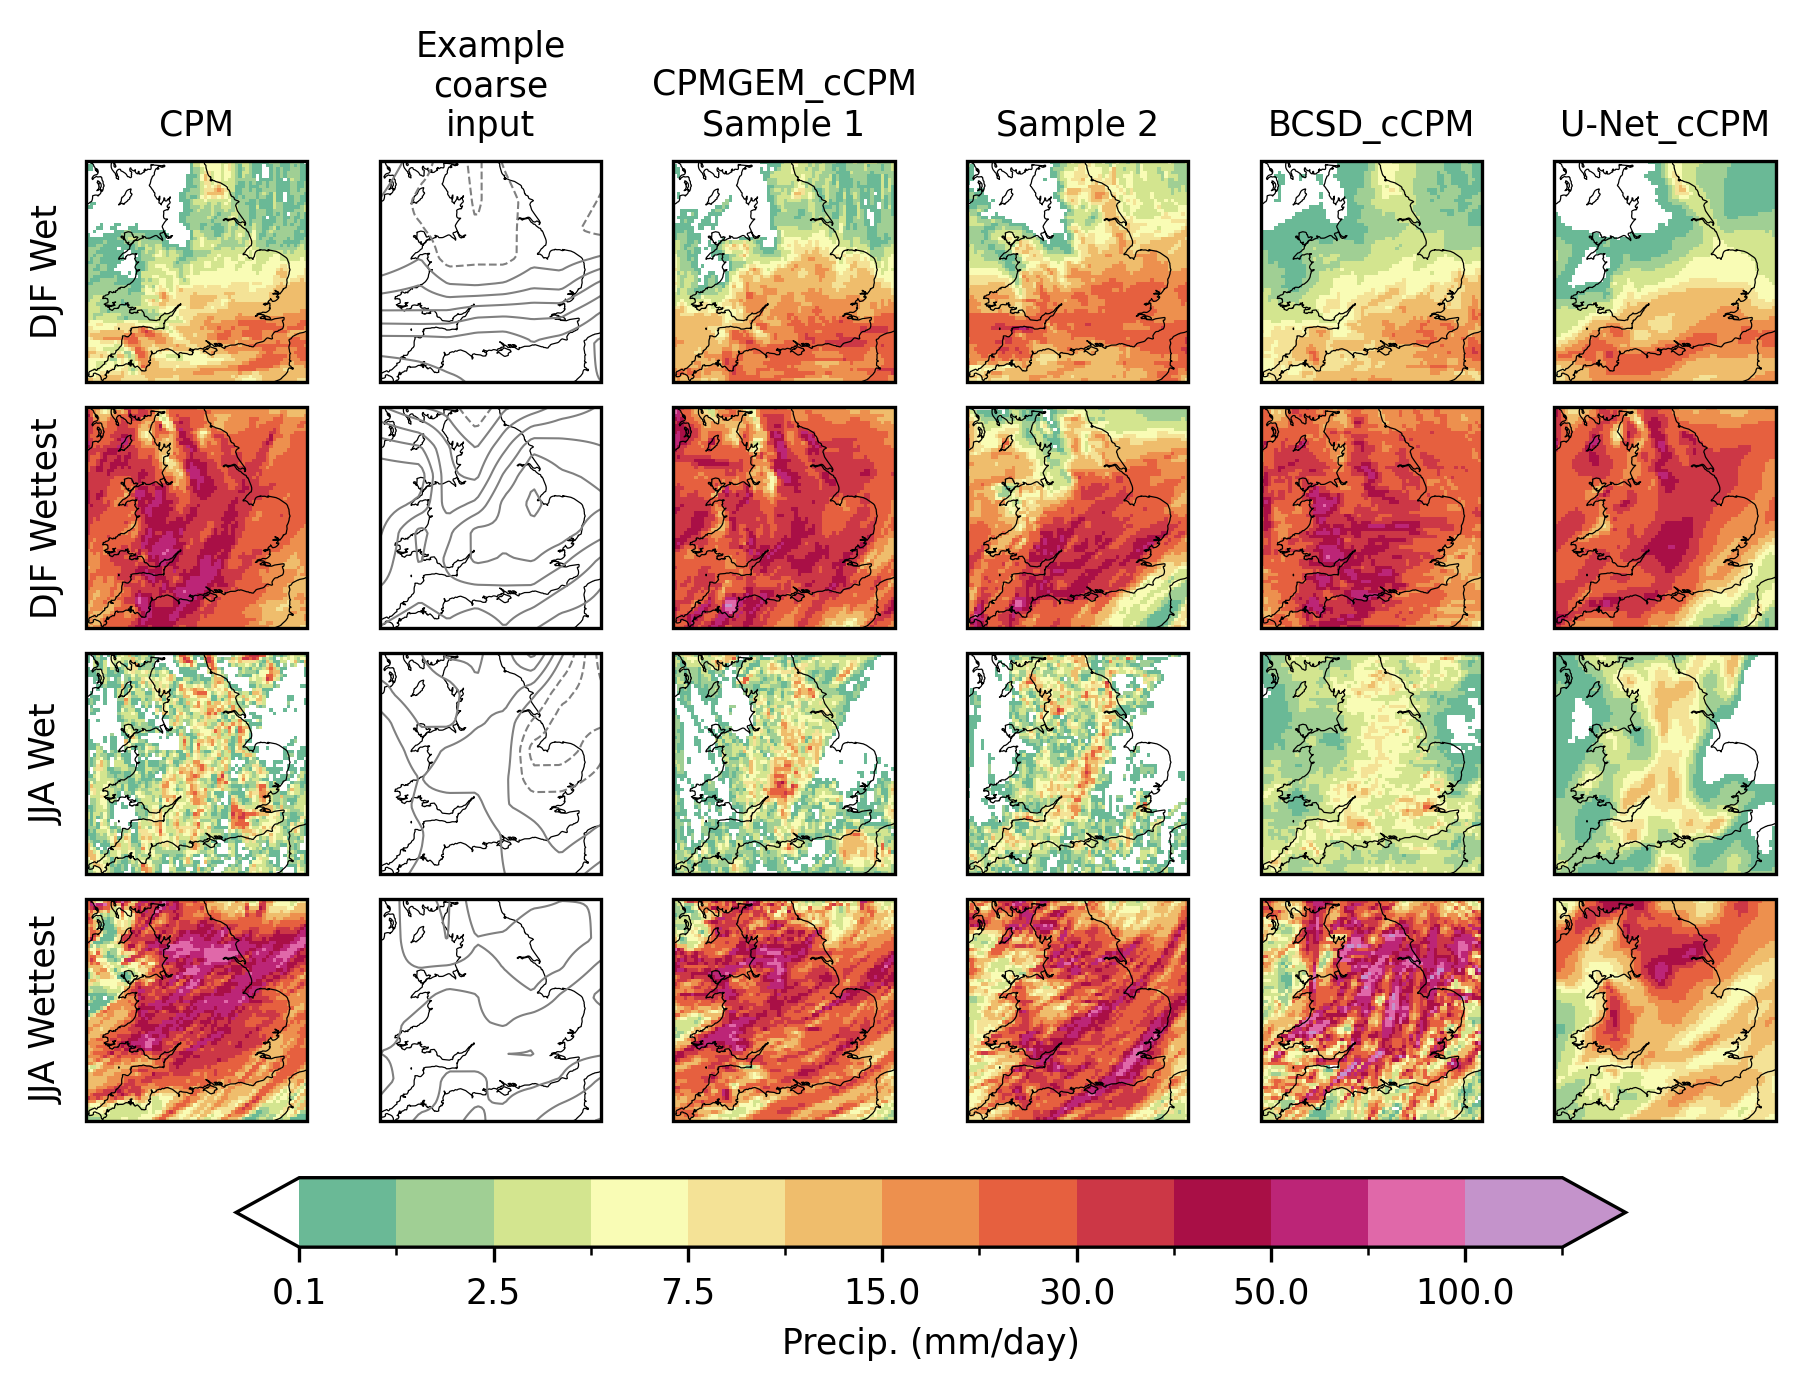

GCM Samples

DJF Wet sample requested for EM04 on 2035-12-12 12:00:00
DJF Wettest sample requested for EM09 on 2075-01-16 12:00:00


JJA Wet sample requested for EM12 on 2035-08-25 12:00:00
JJA Wettest sample requested for EM12 on 2035-08-19 12:00:00


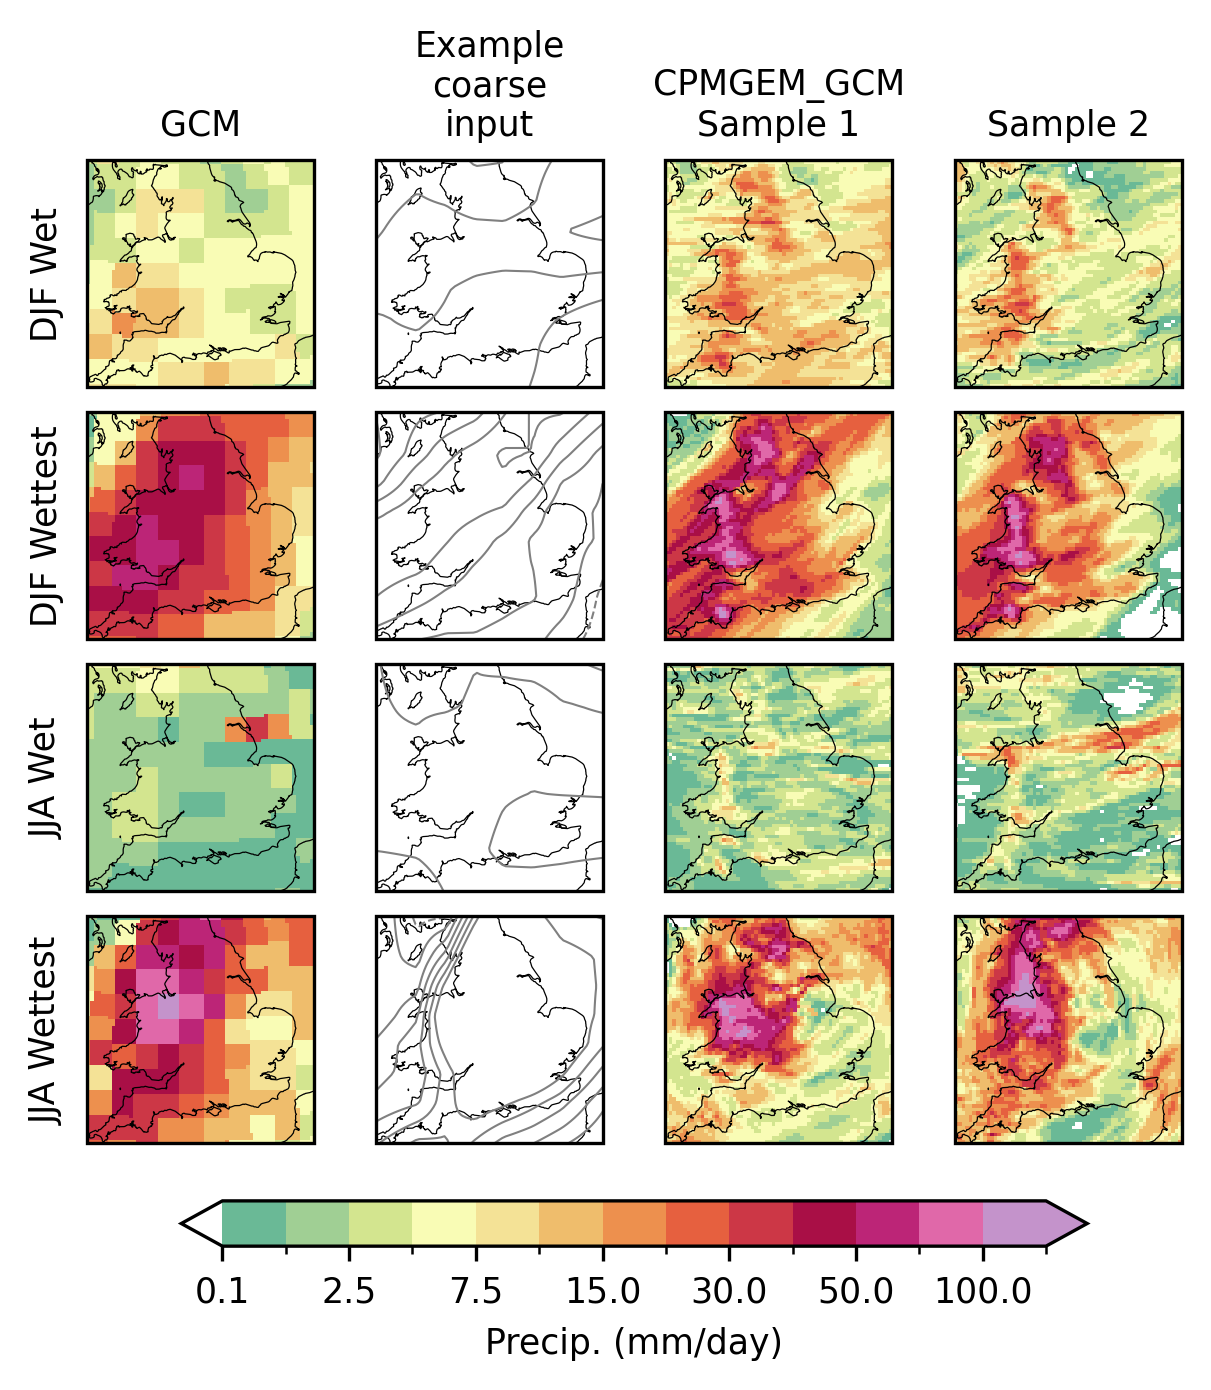

In [ ]:
for source, examples in examples_to_plot.items():
    IPython.display.display_html(f"<h2>{source} Samples</h2>", raw=True)

    if source == "CPM":
        fig_width = 6
    else:
        fig_width = 4
    fig_height = 4.5
    fig = plt.figure(layout="constrained", figsize=(fig_width, fig_height))
    plot_examples(
        EVAL_DS[source], examples,
        vars=eval_vars, models=MODELS[source], fig=fig, sim_title=source, examples_sample_idxs=examples_sample_idxs, inputs=example_inputs,
    )
    plt.show()